## <span style="color: deeppink">Student Performance Prediction</span>
**Intro:** We are going to predict a student's Performance Index based on study habits, sleep, previous scores, and extracurricular activity. 
    We'll compare Linear, Ridge, Lasso and Polynomial regression to find the best fit, then evaluate using MSE, R², and cross-validation.
    
**The Dataset:** 10,000 student records with 6 features and 1 target variable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

In [2]:
data = pd.read_csv("Student_Performance.csv")
data.head(10)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


In [3]:
print(data.shape)
print(data.dtypes)

(10000, 6)
Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities              str
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object


In [4]:
data.isnull().sum() #checking if we have missing values

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [5]:
data.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


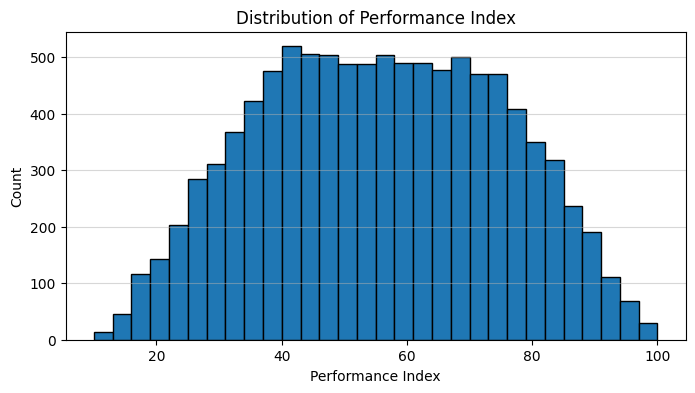

In [6]:
plt.figure(figsize = (8,4))
plt.hist(data['Performance Index'], bins = 30, edgecolor = 'Black')
plt.title('Distribution of Performance Index')
plt.xlabel('Performance Index')
plt.ylabel('Count')
plt.grid(axis = 'y', alpha = 0.5)

<Axes: >

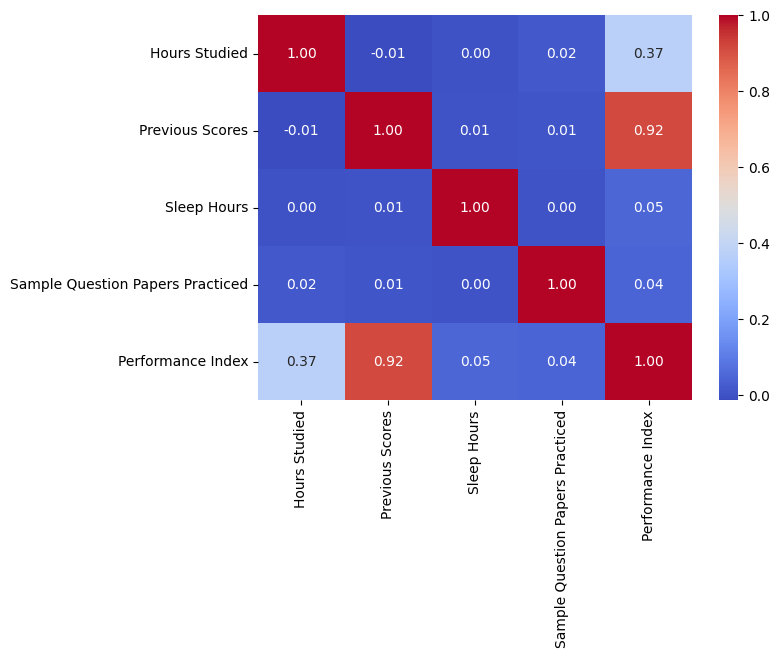

In [7]:
plt.figure(figsize = (7,5))
sns.heatmap(data.corr(numeric_only = True), annot = True, fmt = '.2f', cmap = 'coolwarm')

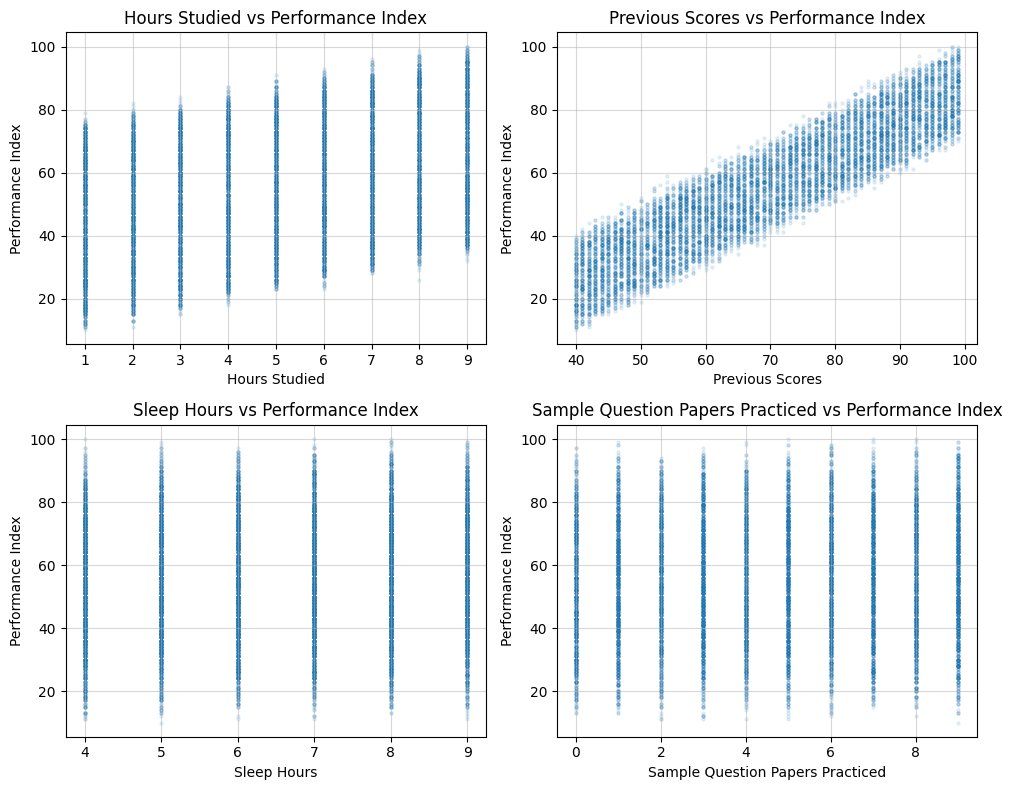

In [8]:
features = []
for i in data.columns[:-1]:
    if i!='Extracurricular Activities':
      features.append(i)
fig, ax = plt.subplots(2, 2, figsize = (10,8))
ax = ax.flatten()
for i, f in enumerate(features):
    ax[i].scatter(data[f], data['Performance Index'], alpha = 0.1,s=5)
    ax[i].set_xlabel(f)
    ax[i].set_ylabel('Performance Index')
    ax[i].set_title(f'{f} vs Performance Index')
    ax[i].grid(alpha = 0.5)

plt.tight_layout()
plt.show()

## **EDA:**
To better understand how much impact each individual column has on the target values a.k.a Performance Index, I displayed heatmap and Column x Performance plots. We can see from the heatmap that 'Previous scores' and 'Performance Index' have positive correlation (r ≈ 0.92), meaning if one of them increases the other does as well (Clearly depicted in corresponding plot). The second column with most impact is 'Hours Studied' column, again with positive correlation (r ≈ 0.40) it affects Performance Index but relatively less. 
The remaining features ('Sleep Hours', 'Sample Question Papers Practiced') have correlation close to zero (r < 0.10), meaning they barely have impact on target values.

In [9]:
data['Extracurricular Activities'] = (data['Extracurricular Activities'] == 'Yes').astype('int8')

In [10]:
x = data.drop('Performance Index', axis=1).values
y = data['Performance Index'].values

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
x_min = x_train.min(axis=0)
x_max = x_train.max(axis=0)
x_train_scaled = (x_train - x_min) / (x_max - x_min)
x_test_scaled = (x_test - x_min) / (x_max - x_min)
print(f"Train: {x_train_scaled.shape}, Test: {x_test_scaled.shape}")
print(f"Target train: {y_train.shape}, Target test: {y_test.shape}")

Train: (8000, 5), Test: (2000, 5)
Target train: (8000,), Target test: (2000,)


In [12]:
def evaluate(name, model, x_train, x_test, y_train, y_test, plotting = False):
    model.fit(x_train, y_train)
    mse1 = mean_squared_error(y_train, model.predict(x_train))
    mse2 = mean_squared_error(y_test, model.predict(x_test))
    r1 = r2_score(y_train, model.predict(x_train))
    r2 = r2_score(y_test, model.predict(x_test))
    print(f'''{name} - Prediction on Training data
                Mse: {mse1}
                R^2: {r1}''')
    print(f'''{name} - Prediction on Testing data
                Mse: {mse2}
                R^2: {r2}''')
    return {'name': name, 'test_r2': r2, 'test_mse': mse2, 'model': model, 'x_test': x_test}



In [13]:
results = []

for name, model in [('Linear',    LinearRegression()),
                    ('Ridge',     Ridge(alpha=0.5)),
                    ('Lasso',     Lasso(alpha=0.5))]:
    results.append(evaluate(name, model, x_train_scaled, x_test_scaled, y_train, y_test))

for degree in range(2, 5):
    poly        = PolynomialFeatures(degree=degree)
    x_tr_poly   = poly.fit_transform(x_train_scaled)
    x_te_poly   = poly.transform(x_test_scaled)
    results.append(evaluate(f'Polynomial deg {degree}', LinearRegression(),
                            x_tr_poly, x_te_poly, y_train, y_test))


Linear - Prediction on Training data
                Mse: 4.169735849525006
                R^2: 0.9886898790682355
Linear - Prediction on Testing data
                Mse: 4.082628398521899
                R^2: 0.9889832909573144
Ridge - Prediction on Training data
                Mse: 4.169919121013703
                R^2: 0.9886893819569615
Ridge - Prediction on Testing data
                Mse: 4.086122120399931
                R^2: 0.9889738633744807
Lasso - Prediction on Training data
                Mse: 10.537037386473239
                R^2: 0.9714190127614171
Lasso - Prediction on Testing data
                Mse: 10.972911442222223
                R^2: 0.9703903071967352
Polynomial deg 2 - Prediction on Training data
                Mse: 4.1642901476113146
                R^2: 0.9887046501591211
Polynomial deg 2 - Prediction on Testing data
                Mse: 4.080643106151687
                R^2: 0.9889886481405484
Polynomial deg 3 - Prediction on Training data
          

In [14]:
results_df = pd.DataFrame(results).drop(columns=['model', 'x_test'])
results_df.sort_values('test_r2', ascending=False)

,name,test_r2,test_mse
3,Polynomial deg 2,0.988989,4.080643
0,Linear,0.988983,4.082628
1,Ridge,0.988974,4.086122
4,Polynomial deg 3,0.988958,4.092151
5,Polynomial deg 4,0.988873,4.123630
2,Lasso,0.970390,10.972911


In [15]:
def plot_predictions(name, model, x_test, y_test):
    y_pred = model.predict(x_test)
    sorted_indices = np.argsort(y_test)
    y_test_sorted   = y_test[sorted_indices]
    y_pred_sorted = y_pred[sorted_indices]

    plt.figure(figsize=(7, 4))
    plt.plot(y_test_sorted, y_test_sorted, color='red', linewidth=1,
             linestyle='--', label='Perfect prediction')
    plt.scatter(y_test_sorted, y_pred_sorted, alpha=0.1, s=5, label='Predicted')
    plt.xlabel('Actual Value')
    plt.ylabel('Predicted Value')
    plt.title(f'{name} — Actual vs Predicted')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

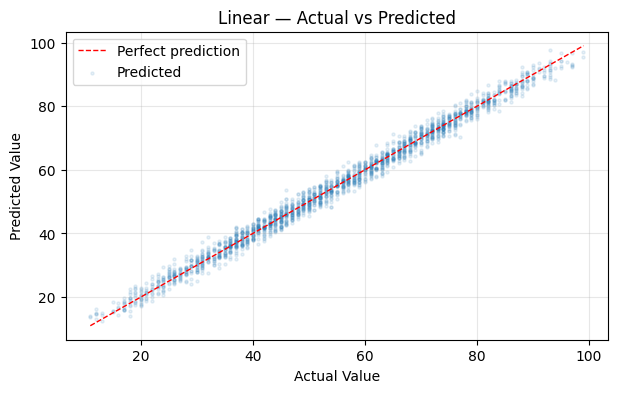

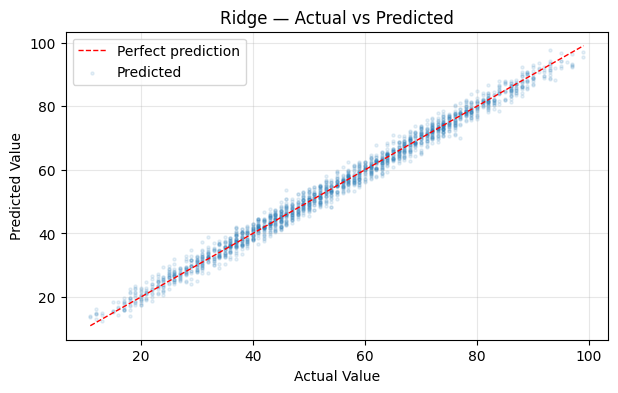

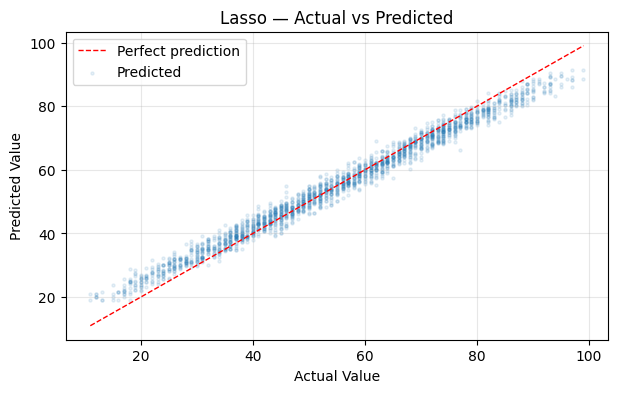

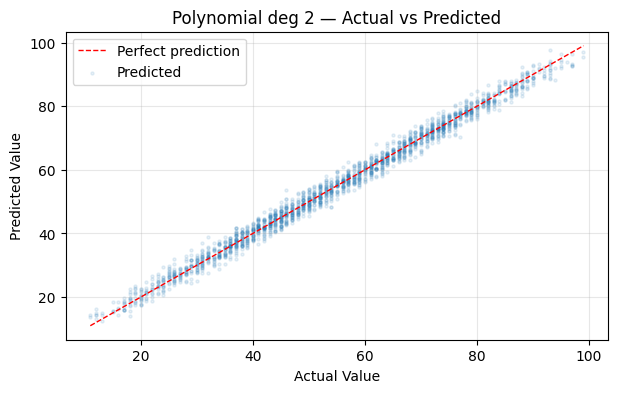

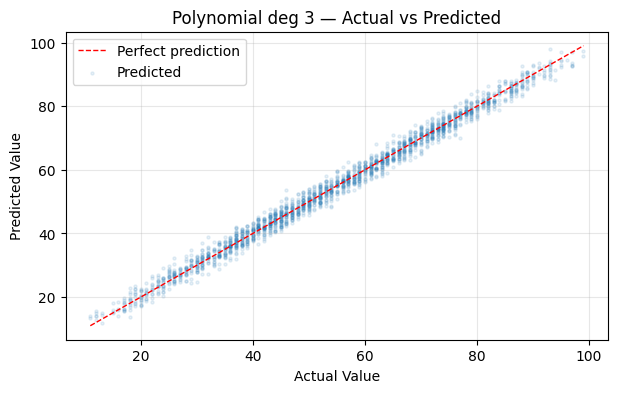

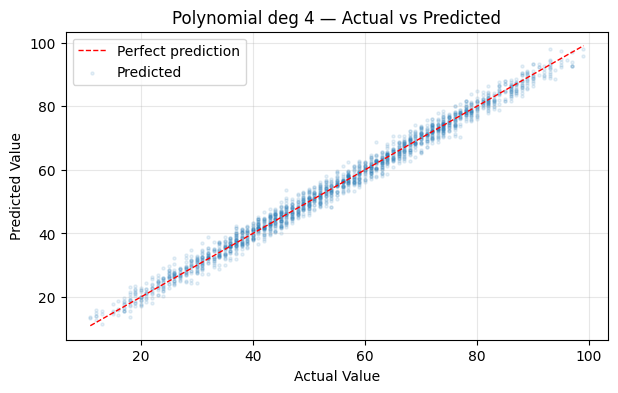

In [16]:
for r in results:
    plot_predictions(r['name'], r['model'], r['x_test'], y_test)

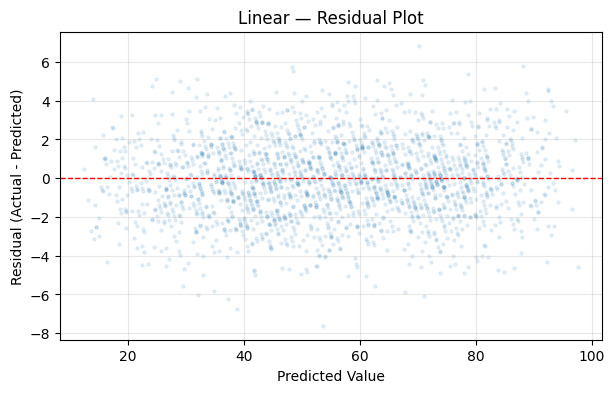

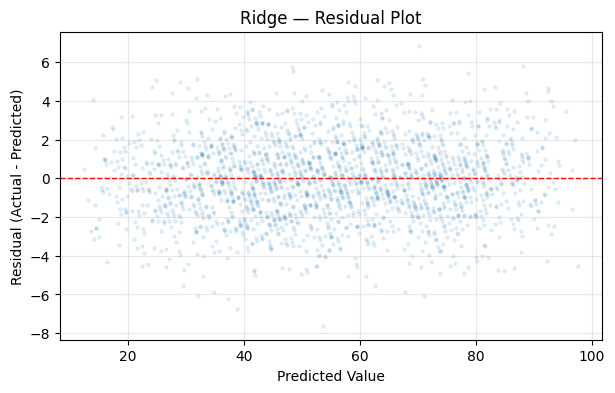

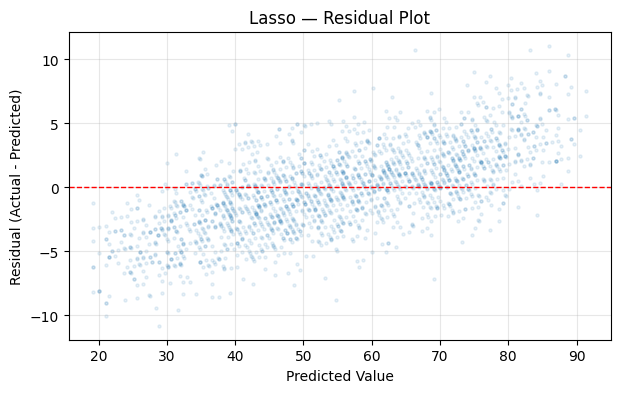

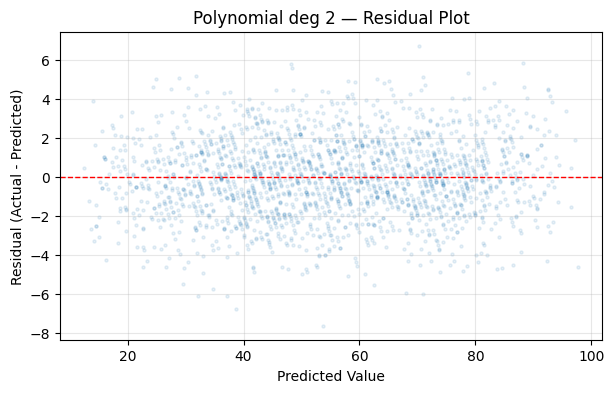

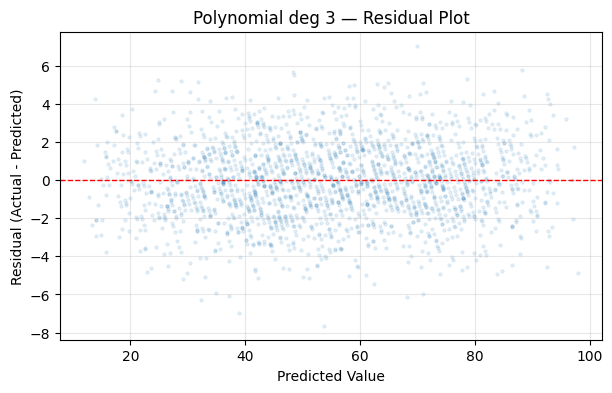

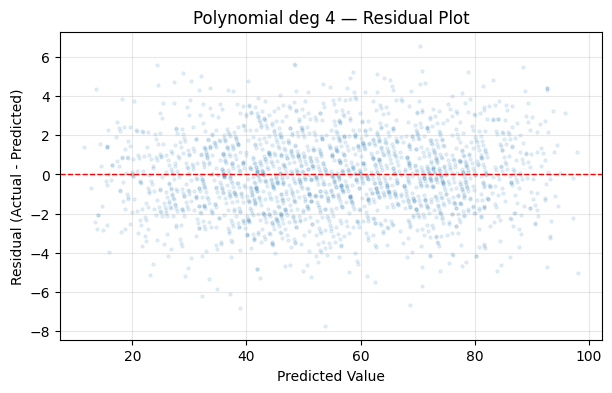

In [17]:
def plot_residuals(name, model, x_test, y_test):
    y_pred    = model.predict(x_test)
    residuals = y_test - y_pred
    plt.figure(figsize=(7, 4))
    plt.scatter(y_pred, residuals, alpha=0.1, s=5)
    plt.axhline(y=0, color='red', linewidth=1, linestyle='--')
    plt.xlabel('Predicted Value')
    plt.ylabel('Residual (Actual - Predicted)')
    plt.title(f'{name} — Residual Plot')
    plt.grid(alpha=0.3)
    plt.show()

for r in results:
    plot_residuals(r['name'], r['model'], r['x_test'], y_test)

In [18]:
from sklearn.model_selection import cross_val_score

print("5-Fold Cross-Validation R² scores:\n")
for name, model in [('Linear', LinearRegression()),
                    ('Ridge',  Ridge(alpha=0.5)),
                    ('Lasso',  Lasso(alpha=0.5))]:
    scores = cross_val_score(model, x_train_scaled, y_train, cv=5, scoring='r2')
    print(f"  {name:10s} →  mean: {scores.mean():.4f}   std: {scores.std():.4f}")

5-Fold Cross-Validation R² scores:

  Linear     →  mean: 0.9887   std: 0.0003
  Ridge      →  mean: 0.9887   std: 0.0003
  Lasso      →  mean: 0.9714   std: 0.0005


## Conclusions

### <span style="color: deeppink">Model performance</span>
All models achieved R² above 0.97 on the test set, indicating that student
performance is highly predictable from the available features.

### <span style="color: deeppink">Winner</span>
Linear Regression and Polynomial degree 2 performed essentially equally
(R² ≈ 0.989), with a difference of less than 0.0001. Given this, plain
Linear Regression is the preferred choice — it is simpler, faster, and
equally accurate.

### <span style="color: deeppink">Key findings from EDA and modeling</span>
- `Previous Scores` (r ≈ 0.92) and `Hours Studied` (r ≈ 0.40) were the
  dominant predictors, as confirmed by both the heatmap and model behavior.
- `Sleep Hours` and `Sample Papers Practiced` showed near-zero individual
  correlation with the target. Lasso confirmed this by penalizing them,
  which slightly reduced its accuracy.
- The near-identical performance of Linear and Ridge regression confirms
  there is no meaningful overfitting or multicollinearity in the dataset.
- Polynomial degrees 3 and 4 performing worse than degree 2 is an early
  sign of overfitting — added complexity without added value.

### <span style="color: deeppink">Cross-validation</span>
Mean R² of 0.9887 with std of 0.0003 confirms the model is highly stable
and not dependent on any particular random split of the data.
